In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy.optimize as opt
import pandas as pd

In [38]:
def datos_lineal(n,sigma):
    """
    Genero n datos tales que siguen una distribución lineal con un cierto ruido
    """
    a = 7
    b = 11
    eps = st.norm.rvs(loc=0, scale=sigma, size=n)  # ruido gaussiano
    x = st.uniform.rvs(loc=3, scale=10, size=n)  # x uniforme
    y = a*x+b + eps

    return x,y

def modelo_lineal(x, parametros):
    """
    """
    y = parametros[0] * x + parametros[1]
    return y

def prior_cte(parametros,cota0,cota1):
    """
    Quiero ver el logaritmo de la probabilidad de los parametros
    """
    if np.all(parametros>cota0) and np.all(parametros<cota1):
        return 0 #devuelve 0 por que estoy pensando en un prior cte
    else:
        return -np.inf

def likelihood(modelo,datos,parametros,sigma):
    """
    Calculo el logaritmo de
    """
    l= -np.sum((datos[i]-modelo(parametros)))
    return l

def fun_lum(x,phi,M,alfa):
    """
    Funcion de Schechter, es el modelo teorico que vamos a ajustar

    --Parametros--
    x: tipo array, valores a evaluar
    phi, M, alfa: tipo reales, parametros de la funcion
    """
    l= 0.4*np.log(10)*phi*10**(-0.4*(x-M)*(1+alfa))*np.e**(-10**(-0.4*(x-M)))
    return l

<Axes: >

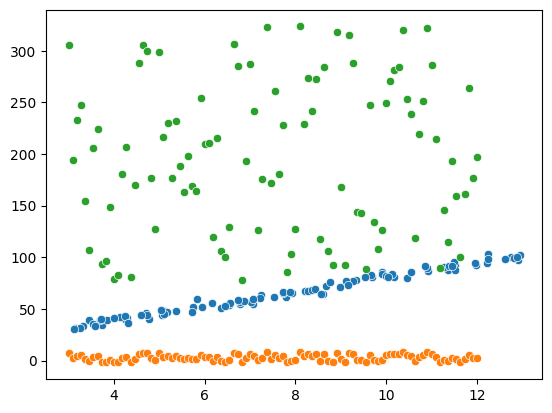

In [41]:
sigma=2.5
x,y = datos_lineal(100,sigma)

par_0=[10,10]
cota_sup=[1,-5]
cota_inf=[25,0]
linea=np.linspace(3,12,100)


sns.scatterplot(x=x,y=y)
sns.scatterplot(x=linea,y=modelo_lineal(x,cota_sup))
sns.scatterplot(x=linea,y=modelo_lineal(x,cota_inf))

In [20]:
df=pd.read_csv('/content/drive/MyDrive/Astrometria/datos_Blanton.csv')
print(df.head())


      MAG       PHI  error_inf  error_sup
0 -23.183  0.000003   0.000001   0.000006
1 -23.020  0.000005   0.000003   0.000011
2 -22.870  0.000017   0.000013   0.000026
3 -22.698  0.000035   0.000025   0.000044
4 -22.565  0.000082   0.000058   0.000105
